# Regression

**Working Example.** Copy this file, rename it, and modify *your* copy.
See earlier notebooks for more information. 

- Author: Kim Hummel, Denise Case
- Date: 2026-06
- Dataset: Seaborn taxis
- Target: fair

Run all cells top to bottom (**Run All**) before pushing to GitHub.

## M4. Regression

This notebook fits a line and computes the numbers analysts use to judge a fit:

- R-squared
- RMSE
- residuals
  
It shows how complexity changes train vs. test error. 

The analyst decides whether the fit is "good" and 
how much complexity is right. 
Code calculates values, but the analyst decides.

Every time we fit a model, we use the same shape: 
setup, load, prepare, model, evaluate, summarize.

Judgment always remains with the analyst.

## Overview

This project uses the penguins dataset.
We choose to predict the target `body_mass_g`.
This target is a **numeric** variable (rather than a discrete category), so we have a:

- supervised ML problem (because we've chosen a target)
- a regression problem (because our target is numeric)

Customize the overview in your copy to reflect your dataset and choices.

## A. Prepare the Project Environment (.venv/)

- Open one project in VS Code at a time.
- Prepare the .venv/: specify Python version and install / upgrade dependencies listed in `pyproject.toml`.
- Open an integrated terminal (PowerShell if Windows) in the **root project** folder and run:

```shell
uv self update
uv python pin 3.14
uv lock --upgrade
uv sync --extra dev --extra docs --upgrade
```

## B. Select the Notebook Kernel

- Click on the **Select Kernel** name in the top-right corner of the notebook interface.
- Choose Python Environments... /
- Choose the recommended local .venv/ from the drop-down menu.
- This will create a new kernel for the notebook and allow the notebook to use packages installed in the .venv/ environment.

## C. Working in Notebooks (Custom Notes)

- To run a cell, press **Ctrl+Enter** (or **Cmd+Enter** on Mac) when done editing the cell.
- Change the type of a cell (e.g., code or markdown) by looking in the lower left corner of the notebook interface.
- Rearrange cells by dragging and dropping them within the notebook.

See [Run Jupyter Notebooks](https://denisecase.github.io/pro-analytics-02/workflow-b-apply-example-project/run-notebook/) for:

- how to **copy a notebook**
- how to release a `project.log` file
- how to deal with a **stuck kernel**
- etc.

## Section 0. When to Use Regression, and How We Judge It

Use **regression** when the target is a **number** - mass, price, temperature,
demand. (A category target is classification, Module 3.)

We judge a regression on held-out data, with:

- **R-squared** - the fraction of the variation in the target the model explains
  (roughly 0 to 1; higher is more).
- **RMSE** - root mean squared error, the typical size of a miss, in the target's units.
- **residual plot** - actual minus predicted. If a straight line fits well, residuals
  scatter randomly around zero with no pattern. A curve or a funnel says the line is
  the wrong shape - itself a useful finding.

**Over- vs. under-fitting:** a model too simple **underfits** (misses real structure;
poor on both train and test). A model too complex **overfits** (memorizes the training
data; great on train, worse on test). You detect it by comparing train and test error
as complexity changes - Section 6.

## Section 1. Project Setup and Imports

In [1]:
# === Section 1a. DECLARE IMPORTS ===

from importlib.metadata import version  # to verify
import logging  # for type hinting
import platform  # to verify
from typing import Final  # for type hinting

from datafun_toolkit.logger import get_logger, log_header
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# === Section 1b. CONFIGURE LOGGER ONCE PER NOTEBOOK ===

LOG: logging.Logger = get_logger("M04", level="DEBUG")
log_header(LOG, "M04")

# === Section 1c. USE THE LOGGER TO VERIFY IMPORTS ===

# If any do NOT return a version number, then that package is not installed correctly.
# Check your pyproject.toml and re-run environment setup commands.

LOG.info("Confirming installation:")
LOG.info(f"  python:       {platform.python_version()}")
LOG.info(f"  pandas:       {version('pandas')}")
LOG.info(f"  numpy:        {version('numpy')}")
LOG.info(f"  scikit-learn: {version('scikit-learn')}")
LOG.info(f"  seaborn:      {version('seaborn')}")
LOG.info(f"  matplotlib:   {version('matplotlib')}")

# === Section 1d. SET PANDAS DISPLAY CONFIGURATION (helps in notebooks) ===

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

2026-07-23 13:55:45 | INFO | M04 | === RUN START ===
2026-07-23 13:55:45 | INFO | M04 | project=M04
2026-07-23 13:55:45 | INFO | M04 | repo_dir=ml-04-regression
2026-07-23 13:55:45 | INFO | M04 | python=3.14.3
2026-07-23 13:55:45 | INFO | M04 | os=Windows 11
2026-07-23 13:55:45 | INFO | M04 | shell=powershell
2026-07-23 13:55:45 | INFO | M04 | cwd=notebooks
2026-07-23 13:55:45 | INFO | M04 | github_actions=False
2026-07-23 13:55:45 | INFO | M04 | Confirming installation:
2026-07-23 13:55:45 | INFO | M04 |   python:       3.14.3
2026-07-23 13:55:45 | INFO | M04 |   pandas:       3.0.3
2026-07-23 13:55:45 | INFO | M04 |   numpy:        2.5.1
2026-07-23 13:55:45 | INFO | M04 |   scikit-learn: 1.9.0
2026-07-23 13:55:45 | INFO | M04 |   seaborn:      0.13.2
2026-07-23 13:55:45 | INFO | M04 |   matplotlib:   3.11.1


## Section 2. Load and Prepare the Data

In [ ]:
# === Section 2. Load and Prepare the Data ===


# CUSTOM: I load a Seaborn dataset by name (no external CSV).
# Change to explore a different dataset.
DATASET_NAME: Final[str] = "taxis"

LOG.info(f"Loading dataset: {DATASET_NAME}")
df: pd.DataFrame = sns.load_dataset(DATASET_NAME)
LOG.info(f"Loaded: {df.shape[0]} rows (instances), {df.shape[1]} columns")

df.head()

2026-07-23 14:06:33 | INFO | M04 | Loading dataset: taxis
2026-07-23 14:06:34 | INFO | M04 | Loaded: 6433 rows (instances), 14 columns


,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan


In [12]:
# CUSTOM: ANALYST CHOICE - one numeric feature (x) and one numeric target (y).
# This pairing is expected to be close to a straight line; we still fit and look.
FEATURE_COL: Final[str] = "distance"
TARGET_COL: Final[str] = "fare"

FEATURE_LABEL: Final[str] = "Distance (miles)"
TARGET_LABEL: Final[str] = "Fare (dollars)"

df_model: pd.DataFrame = df.dropna(subset=[FEATURE_COL, TARGET_COL]).copy()
LOG.info(f"Original rows: {df.shape[0]}  Model rows: {df_model.shape[0]}")

2026-07-23 14:19:57 | INFO | M04 | Original rows: 6433  Model rows: 6433


## Section 3. Split into Train and Test


ANALYST CHOICE

We hold out a test set the model never sees
so R-squared and RMSE reflect new data. 

Without a held-out set we cannot tell a good fit from memorization.

In [7]:
# === Section 3. Split into Train and Test ===

# CUSTOM: ANALYST CHOICE

# Reproducibility for the split and the model.
# Pick any integer, but keep it the same to get the same results.
RANDOM_STATE: Final[int] = 42

"""Build X (2-D) and y (1-D), then split into train and test.

WHY: scikit-learn wants X as shape (n, 1) and y as shape (n,).

Double brackets give a DataFrame (2-D);
single brackets give a Series (1-D).
"""

# Declare X to hold the feature values,
# which will be used for model fitting.
X: np.ndarray = df_model[[FEATURE_COL]].to_numpy()

# Declare y to hold the target values,
# which will be used for model fitting.
y: np.ndarray = df_model[TARGET_COL].to_numpy()

# Declare X_train to hold the training feature values,
# which will be used for model fitting.
X_train: np.ndarray

# Declare X_test to hold the test feature values,
# which will be used for evaluation after model training.
X_test: np.ndarray

# Declare y_train to hold the training target values,
# which will be used for model fitting.
y_train: np.ndarray

# Declare y_test to hold the test target values,
# which will be used for evaluation after model training.
y_test: np.ndarray

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
LOG.info(f"Train instances: {len(X_train)}")
LOG.info(f"Test instances: {len(X_test)}")

2026-07-23 14:15:15 | INFO | M04 | Train instances: 5146
2026-07-23 14:15:15 | INFO | M04 | Test instances: 1287


## Section 4. Fit a Straight Line

In [8]:
# === Section 4. Fit a Straight Line ===


"""
Fit y = slope * x + intercept with scikit-learn.

WHY: create -> .fit() -> read results / .predict()
 is the same pattern for every scikit-learn model.

The model exposes .coef_ (slope) and .intercept_.
"""

LOG.info("Fitting a linear regression (scikit-learn)")

# create a linear regression model object (untrained)
model = LinearRegression()

# fit the model to the training data (learn the slope and intercept)
model.fit(X_train, y_train)

# retrieve the results (slope and intercept) and log them

slope: float = float(model.coef_[0])
intercept: float = float(model.intercept_)

LOG.info(f"Fitted line: {TARGET_COL} = {slope:.6g} * {FEATURE_COL} + {intercept:.6g}")

2026-07-23 14:15:25 | INFO | M04 | Fitting a linear regression (scikit-learn)
2026-07-23 14:15:26 | INFO | M04 | Fitted line: fare = 2.78479 * distance + 4.66844


## Section 5. Evaluate the Model Fit

2026-07-23 14:15:31 | INFO | M04 | Fit numbers on the TEST set (for you to interpret):
2026-07-23 14:15:31 | INFO | M04 |   R-squared: 0.8277
2026-07-23 14:15:31 | INFO | M04 |   RMSE:      4.67388  (in units of Fare (dollars))


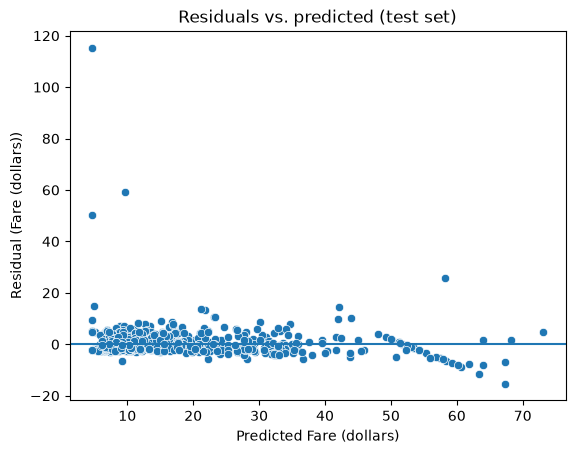

In [9]:
# === Section 5. Evaluate the Model Fit ===

# With regression, we use  R-squared, RMSE, and Residuals

"""
Report test R-squared and RMSE, and show a residual plot.

WHY: These are how the analyst decides
whether the line is a fair description.

This reports them on held-out data;
it does NOT declare the fit good or bad.

The analyst uses the numbers and the residual plot to decide.
"""

y_hat: np.ndarray = model.predict(X_test)

# Use float() to convert from numpy types to native Python types
residuals: np.ndarray = y_test - y_hat
r_squared: float = float(model.score(X_test, y_test))
rmse: float = float(np.sqrt(np.mean(residuals**2)))

LOG.info("Fit numbers on the TEST set (for you to interpret):")
LOG.info(f"  R-squared: {r_squared:.4f}")
LOG.info(f"  RMSE:      {rmse:.6g}  (in units of {TARGET_LABEL})")

# Residual plot: random scatter around 0 means a straight line fits well.

# Start a new figure
plt.figure()

# Create a scatter plot of residuals vs. predicted values
sns.scatterplot(x=y_hat, y=residuals)

# Add a horizontal line at y=0 to help visualize the residuals
plt.axhline(0)

# Label the axes and add a title
plt.xlabel(f"Predicted {TARGET_LABEL}")
plt.ylabel(f"Residual ({TARGET_LABEL})")
plt.title("Residuals vs. predicted (test set)")

# show the plot
plt.show()

### Interpretation

When the fare is under $40 the points cluster around the zero line, but when we get past $40 it tapers off with less data points, some of them forming a negative slope through the zero line. Additionally, there are some outliers under $10. 

This means that generally speaking the line is a good fit, but not as consistent for fares under $10 and fares over $45. 

## Section 6. Detect Over- and Under-Fitting

Fit polynomials of increasing **degree** 
(degree 1 is the straight line) and plot
train vs. test RMSE. 

Underfitting shows as both errors high; 
overfitting shows as train RMSE falling while test RMSE rises. 

The best degree is where **test error is lowest** 
and the train/test gap is small.

The analyst decides which degree that is.

2026-07-23 14:16:03 | DEBUG | M04 |   degree= 1  train RMSE=4.48598  test RMSE=4.67388
2026-07-23 14:16:03 | DEBUG | M04 |   degree= 2  train RMSE=4.4858  test RMSE=4.67111
2026-07-23 14:16:03 | DEBUG | M04 |   degree= 3  train RMSE=4.40592  test RMSE=4.6529
2026-07-23 14:16:03 | DEBUG | M04 |   degree= 4  train RMSE=4.39508  test RMSE=4.64659
2026-07-23 14:16:03 | DEBUG | M04 |   degree= 5  train RMSE=4.39281  test RMSE=4.64976
2026-07-23 14:16:03 | DEBUG | M04 |   degree= 6  train RMSE=4.39129  test RMSE=4.65082
2026-07-23 14:16:03 | DEBUG | M04 |   degree= 7  train RMSE=4.3534  test RMSE=4.62416


2026-07-23 14:16:03 | DEBUG | M04 |   degree= 8  train RMSE=4.35336  test RMSE=4.62228
2026-07-23 14:16:03 | DEBUG | M04 |   degree= 9  train RMSE=4.22879  test RMSE=4.58643
2026-07-23 14:16:03 | DEBUG | M04 |   degree=10  train RMSE=4.22784  test RMSE=4.58684


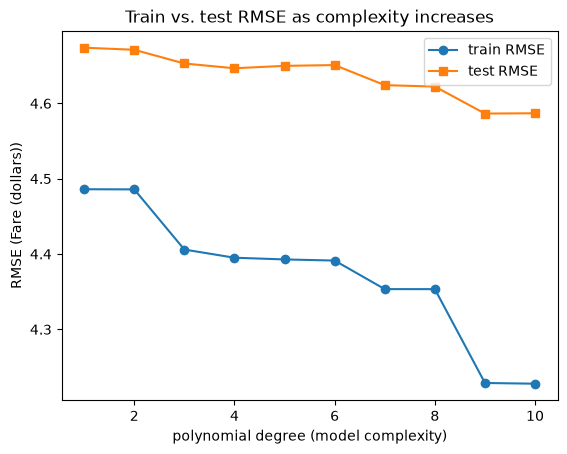

In [10]:
# === Section 6. Detect Over- and Under-Fitting ===

"""Show train vs. test RMSE as polynomial degree increases.

WHY: Error is not a fixed property of "the model"; it moves with complexity.
Watching train and test diverge is how you detect over- and under-fitting and
pick complexity on purpose. numpy fits the polynomial; nothing hidden.
"""

# Call .ravel() to convert from
# shape (n, 1) to shape (n,) for np.polyfit and np.polyval.
x_train: np.ndarray = X_train.ravel()
x_test: np.ndarray = X_test.ravel()

# CUSTOM: ANALYST CHOICE
# for penguins, sweep from 1 to 10 as a good range.
# THIS IS DATA SET DEPENDENT and ANALYST CHOICE.

MAX_SWEEP: Final[int] = 10

# Declare lists to hold the degrees and corresponding train/test RMSE.
degrees: list[int] = list(range(1, MAX_SWEEP + 1))
train_rmse: list[float] = []
test_rmse: list[float] = []

for degree in degrees:
    # Calculate the coefficients of the polynomial fit for the given degree
    coeffs: np.ndarray = np.polyfit(x_train, y_train, degree)

    # Calculate the predicted values for the training and test sets using the polynomial coefficients
    train_pred: np.ndarray = np.polyval(coeffs, x_train)
    test_pred: np.ndarray = np.polyval(coeffs, x_test)

    # Calculate and store the RMSE for the training and test sets
    train_rmse.append(float(np.sqrt(np.mean((y_train - train_pred) ** 2))))
    test_rmse.append(float(np.sqrt(np.mean((y_test - test_pred) ** 2))))
    LOG.debug(
        f"  degree={degree:2d}  train RMSE={train_rmse[-1]:.6g}  test RMSE={test_rmse[-1]:.6g}"
    )

# start a new figure
plt.figure()

# Plot the train and test RMSE against the polynomial degree
# to visualize overfitting and underfitting.
plt.plot(degrees, train_rmse, marker="o", label="train RMSE")
plt.plot(degrees, test_rmse, marker="s", label="test RMSE")

# Label the axes and add a title
plt.xlabel("polynomial degree (model complexity)")
plt.ylabel(f"RMSE ({TARGET_LABEL})")
plt.title("Train vs. test RMSE as complexity increases")

# Add a legend
plt.legend()

# Show the plot
plt.show()

### Interpretation

While they hit their lowest point at 9, they are closest together at 1 degree. Even at their lowest point, the training RMSE decreased by only 0.25814 and the testing RMSE only decreased by 0.08704. With this small of a decrease over the degrees it would make the most sense to stick with the simplest, 1 degree, where the testing and training are the closest together. 

## Section 7. Summary and Next Steps

First, output key information (may use Python)
Second, provide your narrative, conclusions, and next steps (in Markdown)

In [11]:
# === Python Summary ===


"""Record what was fit and the judgment still owed."""
slope: float = float(model.coef_[0])
intercept: float = float(model.intercept_)
LOG.info("========================")
LOG.info("SUMMARY")
LOG.info("========================")
LOG.info(f"Dataset:  {DATASET_NAME}")
LOG.info(f"Feature:  {FEATURE_COL}  ->  Target: {TARGET_COL}  (regression)")
LOG.info(f"Line:     {TARGET_COL} = {slope:.6g} * {FEATURE_COL} + {intercept:.6g}")
LOG.info("========================")

2026-07-23 14:16:27 | INFO | M04 | ========================
2026-07-23 14:16:27 | INFO | M04 | SUMMARY
2026-07-23 14:16:27 | INFO | M04 | ========================
2026-07-23 14:16:27 | INFO | M04 | Dataset:  taxis
2026-07-23 14:16:27 | INFO | M04 | Feature:  distance  ->  Target: fare  (regression)
2026-07-23 14:16:27 | INFO | M04 | Line:     fare = 2.78479 * distance + 4.66844
2026-07-23 14:16:27 | INFO | M04 | ========================



### Custom Narrative

While the RMSE is not the lowest at degree 1, it is when they are the closest between the train and test data. 
Both RMSEs decrease and you increase the degrees, however it the decrease for them is less than 0.3.
Since the decrease in RMSE is so small, it is not worth forgoing the closeness of the RMSEs for it. 
Increasing the degree would increase the complexity with not enough pay off. 

This is proven by how closely the residuals cluster around zero. 
There are some outliers with cheaper fares. And after $45 the residuals are not as random as they should be. 
But the majority of the data has residuals around the zero line, making 1 degree the best option. 

Below the residuals vs predicted are graphed for 1, 5, and 9 degrees. 
The graph is almost the same for all of the degrees. 
This proves that it is best to keep with the simplest as increasing the complexity by increasing the degrees will not significantly change the outcome. 


2026-07-25 08:02:38 | INFO | M04 | Degree 1 test RMSE: 4.67388


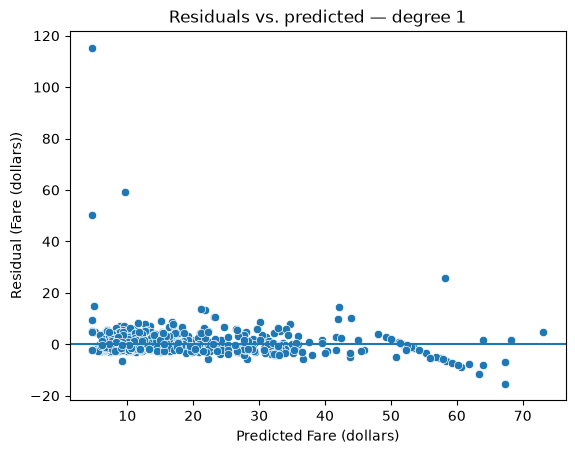

2026-07-25 08:02:38 | INFO | M04 | Degree 5 test RMSE: 4.64976


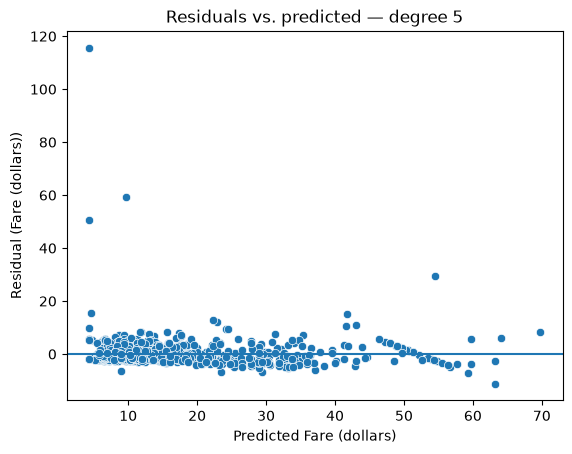

2026-07-25 08:02:39 | INFO | M04 | Degree 9 test RMSE: 4.58643


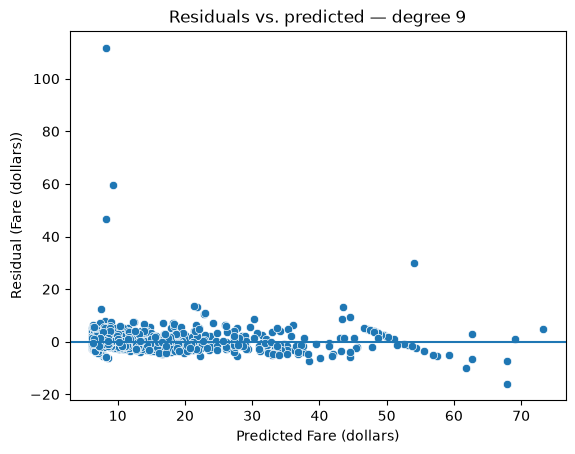

In [14]:
# === Section 8. Extra Experimentation ===
# === Compare residuals at different polynomial degrees ===

# CUSTOM: pick the degrees you want to inspect
degrees_to_check = [1, 5, 9]

for degree in degrees_to_check:
    coeffs = np.polyfit(x_train, y_train, degree)
    y_hat_d = np.polyval(coeffs, x_test)
    residuals_d = y_test - y_hat_d
    rmse_d = float(np.sqrt(np.mean(residuals_d**2)))

    LOG.info(f"Degree {degree} test RMSE: {rmse_d:.6g}")

    plt.figure()
    sns.scatterplot(x=y_hat_d, y=residuals_d)
    plt.axhline(0)
    plt.xlabel(f"Predicted {TARGET_LABEL}")
    plt.ylabel(f"Residual ({TARGET_LABEL})")
    plt.title(f"Residuals vs. predicted — degree {degree}")
    plt.show()